# XGBoost - HR Employee Attrition 

**Goal** Train a XGBoost classifier to predict employee attrition, evaluate it, and export the model + preprocessing pipeline so DiCE can generate counterfactual explanations.

----

Outputs saved for Dice:
- *xgboost.pkl* : trained model
- *scaler.pkl*: StandardScaler fitted on training data
- *feature_names.pkl* : Ordered list of features names
- *label_encoders.pkl*: LabelEncoders for categorical features


# 1. Data Load
## 1.1.Paths 
Loads project paths from utils.py (DATA = data/processed/, RF = data/models/RF/) and reuses the shared SEED constant to guarantee reproducibility across notebooks.

In [1]:
import os
from utils import get_project_paths, SEED_DICE

paths       = get_project_paths()
DATA        = paths["DATA"]
MODELS_PATH = paths["XGBoost"]
os.makedirs(MODELS_PATH, exist_ok=True)

print(f'Preprocessed: {DATA}')
print(f'Models out:   {MODELS_PATH}')

Preprocessed: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\processed
Models out:   c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\models\XGBoost


## 1.2.Imports
If you don't have the packages below in your environment, uncomment the lines below and run this notebook for the first time. If you have everything, ignore this part. 

In [ ]:
'''
%pip install numpy pandas matplotlib scikit-learn
'''

'\n%pip install numpy\n%pip install pandas\n%pip install matplotlib\n%pip install scikit-learn\n'

In [2]:
SEED = SEED_DICE

import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve, average_precision_score
)

warnings.filterwarnings('ignore')
np.random.seed(SEED)

print('✅ Libraries loaded.')

Libraries loaded.


## 1.3.Load Preprocessed Data
Loads the train,validation, and test splits did in notebook 1.Preprocessing.ipynb. Along with the fitted scaler, feature names, and label encoders, we will re-export this with the model so DiCE can reconstruct the same pipeline.

In [3]:
X_train = np.load(os.path.join(DATA,'X_train.npy'))
X_val   = np.load(os.path.join(DATA,'X_val.npy'))
X_test  = np.load(os.path.join(DATA,'X_test.npy'))

y_train = np.load(os.path.join(DATA,'y_train.npy'))
y_val   = np.load(os.path.join(DATA,'y_val.npy'))
y_test  = np.load(os.path.join(DATA,'y_test.npy'))

# train + val for hyperparameter search CV
X_trainval = np.concatenate([X_train, X_val], axis=0)
y_trainval = np.concatenate([y_train, y_val], axis=0)

with open(os.path.join(DATA, 'scaler.pkl'),         'rb') as f: scaler         = pickle.load(f)
with open(os.path.join(DATA, 'feature_names.pkl'),  'rb') as f: feature_names  = pickle.load(f)
with open(os.path.join(DATA, 'label_encoders.pkl'), 'rb') as f: label_encoders = pickle.load(f)

print(f'X_train: {X_train.shape}  |  y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}    |  y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape}   |  y_test:  {y_test.shape}')
print(f'\nFeatures ({len(feature_names)}): {feature_names}')
print(f'\nClass distribution in train — 0 (No): {(y_train==0).sum()} | 1 (Yes): {(y_train==1).sum()}')

X_train: (1029, 30)  |  y_train: (1029,)
X_val:   (220, 30)    |  y_val:   (220,)
X_test:  (221, 30)   |  y_test:  (221,)

Features (30): ['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Class distribution in train — 0 (No): 863 | 1 (Yes): 166


# 2. XGBoost
## 2.1.Hyperparameter Search
XGBoost-specific parameters:
- scale_pos_weight: 
This is similar to the class_weight we use in 2.a.Random Forest; It tells XGBoost how much more to penalize mistakes on the minority class. The ratio is calculated as the number of negative cases divided by the number of positive cases.

- max_depth:
This parameter controls how complex the trees can get. 

- learning_rate:    
This parameter reduces the contribution of each tree to the final prediction. 

- subsample:       
This sets the fraction of rows sampled for each tree, similar to bagging in random forests.

- colsample_bytree: 
This sets the fraction of features sampled for each tree, similar to the max_features parameter in random forests.

- gamma:            
This is the minimum loss reduction required to make a split. It acts as a form of pruning. Using scoring='recall' focuses on detecting attrition cases and aims to minimize false negatives.

In [4]:
neg = (y_trainval == 0).sum()
pos = (y_trainval == 1).sum()

param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [3, 4, 5, 6, 8],
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'subsample':         [0.6, 0.8, 1.0],
    'colsample_bytree':  [0.6, 0.8, 1.0],
    'gamma':             [0, 0.1, 0.5, 1],
    'scale_pos_weight':  [neg/pos, 3, 5, 8],
}

base_xgb = XGBClassifier(
    random_state = SEED,
    eval_metric  = 'logloss',
    verbosity    = 0,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

search = RandomizedSearchCV(
    estimator           = base_xgb,
    param_distributions = param_dist,
    n_iter              = 30,
    scoring             = 'recall',
    cv                  = cv,
    random_state        = SEED,
    n_jobs              = -1,
    verbose             = 1,
    refit               = True,
)

search.fit(X_trainval, y_trainval)

print(f'\n✅ Best CV Recall (Attrition=1): {search.best_score_:.4f}')
print(f'   Best params: {search.best_params_}')

xgb = search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best CV Recall (Attrition=1): 0.6817
   Best params: {'subsample': 0.8, 'scale_pos_weight': 8, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.8}


## 2.2. Optimal Threshold Search
Since we have the problem of imbalanced classes, we do scans of threshold with X_val to find the best thresholds that maximize F1 for Attrition = 1. 

✅ Optimal threshold: 0.592
   Best F1 (Attrition=1) on val: 0.6667


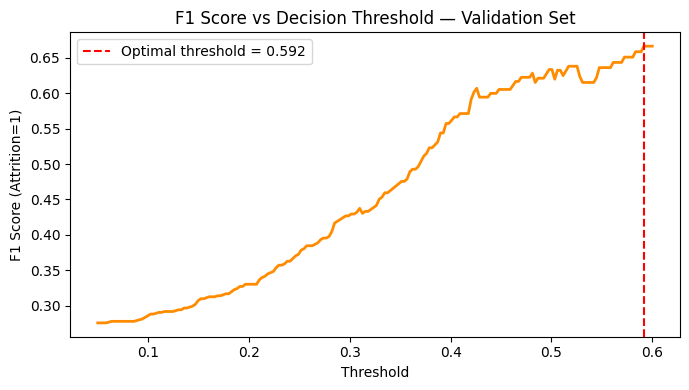

In [ ]:
y_val_proba = xgb.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.05, 0.60, 200)
f1_scores  = [
    f1_score(y_val, (y_val_proba >= t).astype(int), pos_label=1, zero_division=0)
    for t in thresholds
]

THRESHOLD   = thresholds[np.argmax(f1_scores)]
best_f1_val = max(f1_scores)

print(f'✅ Optimal threshold: {THRESHOLD:.3f}')
print(f'   Best F1 (Attrition=1) on val: {best_f1_val:.4f}')
from utils import THRESHOLD_XGB
print(f"Dont forget to save this value in utils.py like THRESHOLD_XGB = {THRESHOLD:.3f} . The registered value now is {THRESHOLD_XGB}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, f1_scores, color='darkorange', linewidth=2)
ax.axvline(THRESHOLD, color='red', linestyle='--', label=f'Optimal threshold = {THRESHOLD:.3f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('F1 Score (Attrition=1)')
ax.set_title('F1 Score vs Decision Threshold — Validation Set')
ax.legend()
plt.tight_layout()
plt.show()

## 2.3. ROC & Precision-Recall Curves
We use the validation set to measure how well the model can distinguish between classes, regardless of the threshold chosen.

We use ROC-AUC, which measures the probability that the model ranks a positive example higher than a negative one. However, since our classes are imbalanced, this metric can be overly optimistic. We use it as a baseline to spot potential issues.

PR-AUC is more suitable for our problem because we want to focus on the minority class and avoid models that have high recall only due to low precision.

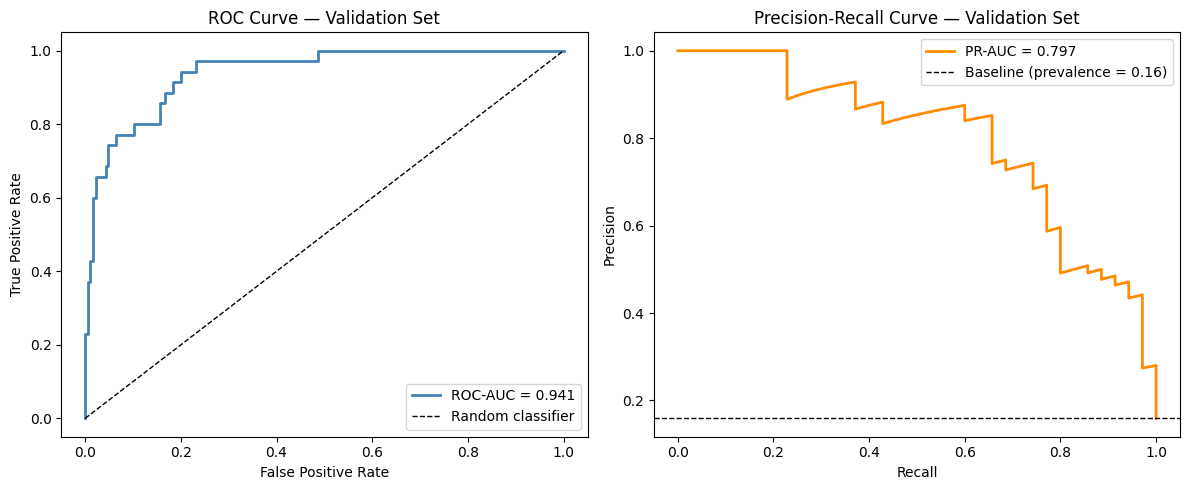

ROC-AUC:  0.9405
PR-AUC:   0.7969


In [16]:
# ROC
fpr, tpr, _          = roc_curve(y_val, y_val_proba)
roc_auc              = auc(fpr, tpr)

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_val, y_val_proba)
pr_auc               = average_precision_score(y_val, y_val_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC-AUC = {roc_auc:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Validation Set')
axes[0].legend()

# PR Curve
axes[1].plot(recall, precision, color='darkorange', lw=2, label=f'PR-AUC = {pr_auc:.3f}')
axes[1].axhline(
    y_val.mean(), color='k', linestyle='--', lw=1,
    label=f'Baseline (prevalence = {y_val.mean():.2f})'
)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Validation Set')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'ROC-AUC:  {roc_auc:.4f}')
print(f'PR-AUC:   {pr_auc:.4f}')

## 2.4. Test Evaluation
We test our dataset using the optimal threshold we chose earlier.
Our main metric is the F1 score for Attrition=1.

In [17]:
y_test_proba = xgb.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_proba >= THRESHOLD).astype(int)

acc          = accuracy_score(y_test, y_test_pred)
f1_weighted  = f1_score(y_test, y_test_pred, average='weighted')
f1_attrition = f1_score(y_test, y_test_pred, pos_label=1)


print(classification_report(y_test, y_test_pred, target_names=['No (0)', 'Yes (1)']))
print(f'Accuracy:          {acc:.3f}')
print(f'F1 (weighted):     {f1_weighted:.3f}')
print(f'F1 (Attrition=1):  {f1_attrition:.3f}  ← primary metric')

              precision    recall  f1-score   support

      No (0)       0.92      0.84      0.88       185
     Yes (1)       0.43      0.61      0.51        36

    accuracy                           0.81       221
   macro avg       0.67      0.73      0.69       221
weighted avg       0.84      0.81      0.82       221

Accuracy:          0.805
F1 (weighted):     0.818
F1 (Attrition=1):  0.506  ← primary metric


## 2.5. Confusion Matrix
By setting the threshold below 0.5, we accept more false positives, meaning some employees are flagged as leaving even though they stay. This helps reduce false negatives, where employees who actually leave go undetected. We found the best balance using the validation set.

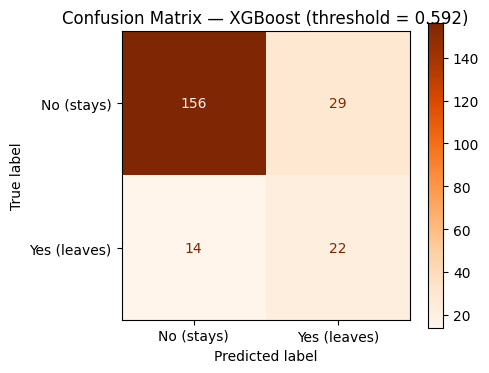

In [18]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    display_labels=['No (stays)', 'Yes (leaves)'],
    cmap='Oranges',
    ax=ax
)
ax.set_title(f'Confusion Matrix — XGBoost (threshold = {THRESHOLD:.3f})')
plt.tight_layout()
plt.show()

## 2.6. Feature Importances MDI
When we use 'importance_type=gain', you measure the average reduction in loss that each feature provides across all splits where it is used. This method provides more useful information than the default 'weight', which does not account for how helpful each split was

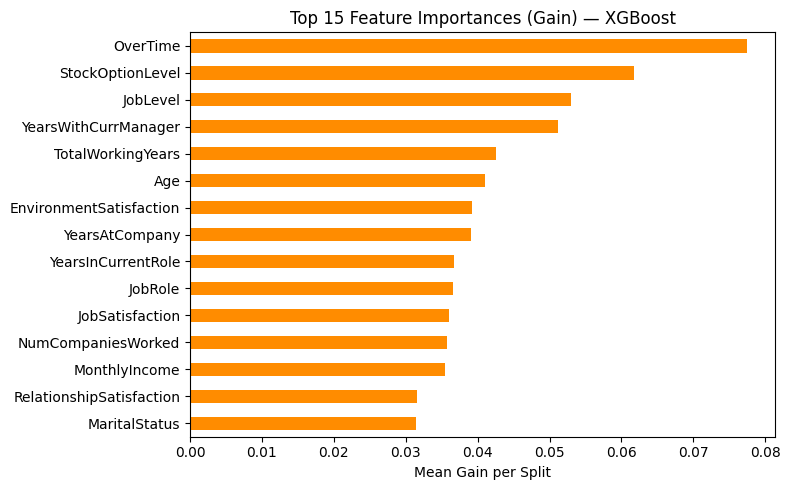

In [19]:
xgb.importance_type = 'gain'  # switch from default 'weight' to 'gain'

importances = pd.Series(xgb.feature_importances_, index=feature_names)
top15       = importances.nlargest(15)

fig, ax = plt.subplots(figsize=(8, 5))
top15.sort_values().plot(kind='barh', color='darkorange', ax=ax)
ax.set_title('Top 15 Feature Importances (Gain) — XGBoost')
ax.set_xlabel('Mean Gain per Split')
plt.tight_layout()
plt.show()

# 3.Save Artifacts for Dice
Saves all the objects that DiCE needs to rebuild the setup
This ensures the preprocessing pipeline can be exactly recreated and valid counterfactuals can be generated.

- xgboost.pkl: the best estimator found by RandomizedSearchCV
- feature_names.pkl: ordered list of features (column order is important for DiCE)
- label_encoders.pkl: LabelEncoders for each categorical feature
- scaler.pkl: StandardScaler fitted on X_train


In [20]:
artifacts = {
    'xgboost.pkl':        xgb,
    'feature_names.pkl':  feature_names,
    'label_encoders.pkl': label_encoders,
    'scaler.pkl':         scaler,
}

for filename, obj in artifacts.items():
    path = os.path.join(MODELS_PATH, filename)
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f'✅ Saved: {path}')

print(f'\n📦 All artifacts saved.')
print(f'   Best hyperparams: {search.best_params_}')
print(f'   Optimal threshold: {THRESHOLD:.3f}')

✅ Saved: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\models\XGBoost\xgboost.pkl
✅ Saved: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\models\XGBoost\feature_names.pkl
✅ Saved: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\models\XGBoost\label_encoders.pkl
✅ Saved: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\models\XGBoost\scaler.pkl

📦 All artifacts saved.
   Best hyperparams: {'subsample': 0.8, 'scale_pos_weight': 8, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.8}
   Optimal threshold: 0.592


## 3.1. Optional Upload to Google Drive

In [21]:
try:
    from google.colab import drive as _drive
    _drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    DRIVE_MODELS = '/content/drive/MyDrive/Current_Trends_in_AI/models/XGBoost'
    os.makedirs(DRIVE_MODELS, exist_ok=True)
    for fname in ['xgboost.pkl', 'scaler.pkl', 'feature_names.pkl', 'label_encoders.pkl']:
        shutil.copy(os.path.join(MODELS_PATH, fname), os.path.join(DRIVE_MODELS, fname))
        print(f'☁️  {fname}')
    print('✅ All XGBoost artifacts uploaded to Drive.')
else:
    print('Not in Colab — skipping Drive upload.')

Not in Colab — skipping Drive upload.
